In [1]:
import os
import random
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import transforms

# Фиксируем seed для воспроизводимости
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ## 2. Данные и DataLoader

# Трансформации: ToTensor + нормализация
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

Device: cpu


In [2]:
# Загрузка EMNIST Balanced
train_full = torchvision.datasets.EMNIST(
    root='./data', split='balanced', train=True, download=True, transform=transform
)
test_ds = torchvision.datasets.EMNIST(
    root='./data', split='balanced', train=False, download=True, transform=transform
)

NUM_CLASSES = 47
print("Train full size:", len(train_full))
print("Test size:", len(test_ds))
print("Number of classes:", NUM_CLASSES)

# Разделение train на train/val (80/20)
val_size = int(0.2 * len(train_full))
train_size = len(train_full) - val_size
generator = torch.Generator().manual_seed(SEED)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=generator)

Train full size: 112800
Test size: 18800
Number of classes: 47


In [3]:
# Параметры загрузки
BATCH_SIZE = 128
NUM_WORKERS = 2 if os.name != 'nt' else 0

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)

# Sanity‑check
x_batch, y_batch = next(iter(train_loader))
print("x_batch shape:", x_batch.shape, "dtype:", x_batch.dtype)
print("y_batch shape:", y_batch.shape, "dtype:", y_batch.dtype)


x_batch shape: torch.Size([128, 1, 28, 28]) dtype: torch.float32
y_batch shape: torch.Size([128]) dtype: torch.int64


C:\Users\Ivan\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [4]:
class MLP(nn.Module):
    def __init__(self, input_dim=784, hidden_dims=(256,128), num_classes=47,
                 dropout_p=0.0, use_batchnorm=False):
        super().__init__()
        layers = [nn.Flatten()]
        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if dropout_p > 0:
                layers.append(nn.Dropout(dropout_p))
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_samples += bs
    return total_loss / total_samples, total_correct / total_samples

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_samples += bs
    return total_loss / total_samples, total_correct / total_samples

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score, model):
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False
        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False
        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

def fit(model, train_loader, val_loader, optimizer, criterion, epochs, early_stopping=None, verbose=True):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    for epoch in range(1, epochs+1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        if verbose:
            print(f"Epoch {epoch:02d}/{epochs} | train loss {tr_loss:.4f}, acc {tr_acc:.4f} | val loss {val_loss:.4f}, acc {val_acc:.4f}")
        if early_stopping is not None:
            if early_stopping.step(val_acc, model):
                print(f"Early stopping triggered at epoch {epoch}")
                early_stopping.restore_best(model)
                break
    return history

In [5]:
# Создаём папку для артефактов
os.makedirs('artifacts/figures', exist_ok=True)

# Общие параметры
INPUT_DIM = 28*28
HIDDEN_DIMS = (256, 128)
EPOCHS = 10
LR = 1e-3
criterion = nn.CrossEntropyLoss()

# Список для сбора результатов
results = []

In [6]:
# **E1: Baseline** (без dropout, без batchnorm)
print("\n=== E1: Baseline (no dropout, no batchnorm) ===")
model_e1 = MLP(INPUT_DIM, HIDDEN_DIMS, NUM_CLASSES, dropout_p=0.0, use_batchnorm=False).to(device)
optimizer_e1 = optim.Adam(model_e1.parameters(), lr=LR)
hist_e1 = fit(model_e1, train_loader, val_loader, optimizer_e1, criterion, epochs=EPOCHS, early_stopping=None)
best_val_acc_e1 = max(hist_e1['val_acc'])
best_val_loss_e1 = min(hist_e1['val_loss'])
results.append({
    'experiment_id': 'E1',
    'dataset': 'EMNIST_BALANCED',
    'seed': SEED,
    'model_summary': 'hidden=(256,128), act=ReLU, dropout=0.0, batchnorm=False',
    'optimizer': 'Adam',
    'lr': LR,
    'momentum': '',
    'weight_decay': 0.0,
    'epochs_trained': len(hist_e1['val_acc']),
    'best_val_accuracy': best_val_acc_e1,
    'best_val_loss': best_val_loss_e1
})


=== E1: Baseline (no dropout, no batchnorm) ===
Epoch 01/10 | train loss 1.3375, acc 0.6194 | val loss 0.8931, acc 0.7262
Epoch 02/10 | train loss 0.7480, acc 0.7666 | val loss 0.6868, acc 0.7856
Epoch 03/10 | train loss 0.6170, acc 0.7997 | val loss 0.6047, acc 0.8083
Epoch 04/10 | train loss 0.5444, acc 0.8189 | val loss 0.5928, acc 0.8082
Epoch 05/10 | train loss 0.5014, acc 0.8304 | val loss 0.5600, acc 0.8197
Epoch 06/10 | train loss 0.4681, acc 0.8394 | val loss 0.5316, acc 0.8277
Epoch 07/10 | train loss 0.4419, acc 0.8477 | val loss 0.5280, acc 0.8259
Epoch 08/10 | train loss 0.4221, acc 0.8525 | val loss 0.5526, acc 0.8208
Epoch 09/10 | train loss 0.4027, acc 0.8572 | val loss 0.5149, acc 0.8344
Epoch 10/10 | train loss 0.3898, acc 0.8612 | val loss 0.5172, acc 0.8341


In [7]:
# **E2: Dropout** (p=0.3)
print("\n=== E2: Dropout p=0.3 ===")
model_e2 = MLP(INPUT_DIM, HIDDEN_DIMS, NUM_CLASSES, dropout_p=0.3, use_batchnorm=False).to(device)
optimizer_e2 = optim.Adam(model_e2.parameters(), lr=LR)
hist_e2 = fit(model_e2, train_loader, val_loader, optimizer_e2, criterion, epochs=EPOCHS)
best_val_acc_e2 = max(hist_e2['val_acc'])
best_val_loss_e2 = min(hist_e2['val_loss'])
results.append({
    'experiment_id': 'E2',
    'dataset': 'EMNIST_BALANCED',
    'seed': SEED,
    'model_summary': 'hidden=(256,128), act=ReLU, dropout=0.3, batchnorm=False',
    'optimizer': 'Adam',
    'lr': LR,
    'momentum': '',
    'weight_decay': 0.0,
    'epochs_trained': len(hist_e2['val_acc']),
    'best_val_accuracy': best_val_acc_e2,
    'best_val_loss': best_val_loss_e2
})


=== E2: Dropout p=0.3 ===
Epoch 01/10 | train loss 1.6513, acc 0.5234 | val loss 0.9182, acc 0.7265
Epoch 02/10 | train loss 1.0695, acc 0.6729 | val loss 0.7548, acc 0.7666
Epoch 03/10 | train loss 0.9451, acc 0.7056 | val loss 0.6876, acc 0.7834
Epoch 04/10 | train loss 0.8838, acc 0.7224 | val loss 0.6339, acc 0.7973
Epoch 05/10 | train loss 0.8398, acc 0.7341 | val loss 0.6270, acc 0.8011
Epoch 06/10 | train loss 0.8067, acc 0.7432 | val loss 0.5932, acc 0.8099
Epoch 07/10 | train loss 0.7835, acc 0.7496 | val loss 0.5856, acc 0.8091
Epoch 08/10 | train loss 0.7700, acc 0.7533 | val loss 0.5711, acc 0.8124
Epoch 09/10 | train loss 0.7571, acc 0.7553 | val loss 0.5682, acc 0.8149
Epoch 10/10 | train loss 0.7417, acc 0.7578 | val loss 0.5548, acc 0.8187


In [8]:
# **E3: BatchNorm**
print("\n=== E3: BatchNorm ===")
model_e3 = MLP(INPUT_DIM, HIDDEN_DIMS, NUM_CLASSES, dropout_p=0.0, use_batchnorm=True).to(device)
optimizer_e3 = optim.Adam(model_e3.parameters(), lr=LR)
hist_e3 = fit(model_e3, train_loader, val_loader, optimizer_e3, criterion, epochs=EPOCHS)
best_val_acc_e3 = max(hist_e3['val_acc'])
best_val_loss_e3 = min(hist_e3['val_loss'])
results.append({
    'experiment_id': 'E3',
    'dataset': 'EMNIST_BALANCED',
    'seed': SEED,
    'model_summary': 'hidden=(256,128), act=ReLU, dropout=0.0, batchnorm=True',
    'optimizer': 'Adam',
    'lr': LR,
    'momentum': '',
    'weight_decay': 0.0,
    'epochs_trained': len(hist_e3['val_acc']),
    'best_val_accuracy': best_val_acc_e3,
    'best_val_loss': best_val_loss_e3
})


=== E3: BatchNorm ===
Epoch 01/10 | train loss 0.9917, acc 0.7310 | val loss 0.6169, acc 0.8038
Epoch 02/10 | train loss 0.5286, acc 0.8258 | val loss 0.5379, acc 0.8213
Epoch 03/10 | train loss 0.4510, acc 0.8450 | val loss 0.4849, acc 0.8387
Epoch 04/10 | train loss 0.4021, acc 0.8594 | val loss 0.4743, acc 0.8416
Epoch 05/10 | train loss 0.3687, acc 0.8682 | val loss 0.4657, acc 0.8438
Epoch 06/10 | train loss 0.3434, acc 0.8747 | val loss 0.4544, acc 0.8481
Epoch 07/10 | train loss 0.3223, acc 0.8806 | val loss 0.4608, acc 0.8480
Epoch 08/10 | train loss 0.3045, acc 0.8849 | val loss 0.4609, acc 0.8490
Epoch 09/10 | train loss 0.2886, acc 0.8909 | val loss 0.4711, acc 0.8453
Epoch 10/10 | train loss 0.2724, acc 0.8960 | val loss 0.4783, acc 0.8436


In [9]:
# Выбираем лучший из E2/E3 по val_accuracy для E4
if best_val_acc_e2 >= best_val_acc_e3:
    best_config_for_E4 = {
        'dropout_p': 0.3,
        'use_batchnorm': False,
        'source': 'E2'
    }
    best_val_acc_E4_ref = best_val_acc_e2
else:
    best_config_for_E4 = {
        'dropout_p': 0.0,
        'use_batchnorm': True,
        'source': 'E3'
    }
    best_val_acc_E4_ref = best_val_acc_e3

print(f"\nЛучший из E2/E3: {best_config_for_E4['source']} с val_acc={best_val_acc_E4_ref:.4f}")

# **E4: EarlyStopping** на лучшей конфигурации
print("\n=== E4: EarlyStopping с лучшей конфигурацией ===")
model_e4 = MLP(INPUT_DIM, HIDDEN_DIMS, NUM_CLASSES,
               dropout_p=best_config_for_E4['dropout_p'],
               use_batchnorm=best_config_for_E4['use_batchnorm']).to(device)
optimizer_e4 = optim.Adam(model_e4.parameters(), lr=LR)
early_stopping = EarlyStopping(patience=4, min_delta=0.0005)
hist_e4 = fit(model_e4, train_loader, val_loader, optimizer_e4, criterion,
              epochs=EPOCHS*2, early_stopping=early_stopping, verbose=True)

best_val_acc_e4 = max(hist_e4['val_acc'])
best_val_loss_e4 = min(hist_e4['val_loss'])
results.append({
    'experiment_id': 'E4',
    'dataset': 'EMNIST_BALANCED',
    'seed': SEED,
    'model_summary': f"hidden=(256,128), act=ReLU, dropout={best_config_for_E4['dropout_p']}, batchnorm={best_config_for_E4['use_batchnorm']}",
    'optimizer': 'Adam',
    'lr': LR,
    'momentum': '',
    'weight_decay': 0.0,
    'epochs_trained': len(hist_e4['val_acc']),
    'best_val_accuracy': best_val_acc_e4,
    'best_val_loss': best_val_loss_e4
})

# Сохраняем лучшую модель (E4) и её конфиг
torch.save(model_e4.state_dict(), 'artifacts/best_model.pt')
best_config = {
    'input_dim': INPUT_DIM,
    'hidden_dims': list(HIDDEN_DIMS),
    'num_classes': NUM_CLASSES,
    'dropout_p': best_config_for_E4['dropout_p'],
    'use_batchnorm': best_config_for_E4['use_batchnorm'],
    'activation': 'ReLU',
    'optimizer': 'Adam',
    'lr': LR,
    'batch_size': BATCH_SIZE,
    'seed': SEED,
    'dataset': 'EMNIST_BALANCED',
    'early_stopping_patience': 4,
    'best_val_accuracy': best_val_acc_e4
}
with open('artifacts/best_config.json', 'w') as f:
    json.dump(best_config, f, indent=4)


Лучший из E2/E3: E3 с val_acc=0.8490

=== E4: EarlyStopping с лучшей конфигурацией ===
Epoch 01/20 | train loss 0.9921, acc 0.7295 | val loss 0.6368, acc 0.7919
Epoch 02/20 | train loss 0.5238, acc 0.8273 | val loss 0.5092, acc 0.8321
Epoch 03/20 | train loss 0.4449, acc 0.8471 | val loss 0.4961, acc 0.8345
Epoch 04/20 | train loss 0.4015, acc 0.8583 | val loss 0.4695, acc 0.8431
Epoch 05/20 | train loss 0.3658, acc 0.8681 | val loss 0.4620, acc 0.8430
Epoch 06/20 | train loss 0.3420, acc 0.8759 | val loss 0.4581, acc 0.8462
Epoch 07/20 | train loss 0.3189, acc 0.8832 | val loss 0.4568, acc 0.8446
Epoch 08/20 | train loss 0.3008, acc 0.8882 | val loss 0.4618, acc 0.8474
Epoch 09/20 | train loss 0.2863, acc 0.8921 | val loss 0.4779, acc 0.8442
Epoch 10/20 | train loss 0.2723, acc 0.8956 | val loss 0.4745, acc 0.8486
Epoch 11/20 | train loss 0.2595, acc 0.9001 | val loss 0.4788, acc 0.8466
Epoch 12/20 | train loss 0.2461, acc 0.9053 | val loss 0.4804, acc 0.8451
Epoch 13/20 | train loss

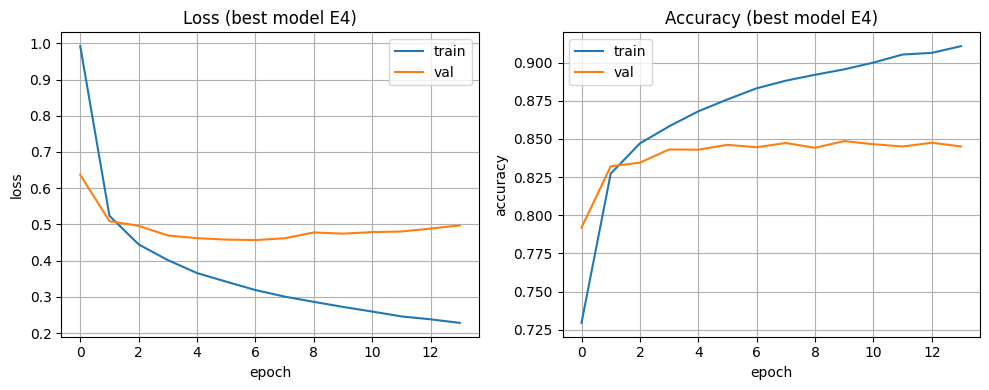

In [10]:
# График для лучшей модели
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(hist_e4['train_loss'], label='train')
plt.plot(hist_e4['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Loss (best model E4)')
plt.legend()
plt.grid(True)
plt.subplot(1,2,2)
plt.plot(hist_e4['train_acc'], label='train')
plt.plot(hist_e4['val_acc'], label='val')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('Accuracy (best model E4)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('artifacts/figures/curves_best.png', dpi=150)
plt.show()

In [11]:
# Используем архитектуру из E4 (best_config)

# **O1: слишком большой LR**
print("\n=== O1: Adam LR too high (1e-1) ===")
model_o1 = MLP(INPUT_DIM, HIDDEN_DIMS, NUM_CLASSES,
               dropout_p=best_config_for_E4['dropout_p'],
               use_batchnorm=best_config_for_E4['use_batchnorm']).to(device)
optimizer_o1 = optim.Adam(model_o1.parameters(), lr=1e-1)
hist_o1 = fit(model_o1, train_loader, val_loader, optimizer_o1, criterion, epochs=6, verbose=True)
best_val_acc_o1 = max(hist_o1['val_acc']) if hist_o1['val_acc'] else float('nan')
best_val_loss_o1 = min(hist_o1['val_loss']) if hist_o1['val_loss'] else float('nan')
results.append({
    'experiment_id': 'O1',
    'dataset': 'EMNIST_BALANCED',
    'seed': SEED,
    'model_summary': 'same as E4',
    'optimizer': 'Adam',
    'lr': 1e-1,
    'momentum': '',
    'weight_decay': 0.0,
    'epochs_trained': len(hist_o1['val_acc']),
    'best_val_accuracy': best_val_acc_o1,
    'best_val_loss': best_val_loss_o1
})


=== O1: Adam LR too high (1e-1) ===
Epoch 01/6 | train loss 1.1040, acc 0.6679 | val loss 0.8624, acc 0.7319
Epoch 02/6 | train loss 0.7790, acc 0.7525 | val loss 0.7522, acc 0.7574
Epoch 03/6 | train loss 0.7104, acc 0.7706 | val loss 0.7263, acc 0.7707
Epoch 04/6 | train loss 0.6658, acc 0.7827 | val loss 0.6630, acc 0.7884
Epoch 05/6 | train loss 0.6280, acc 0.7937 | val loss 0.6784, acc 0.7862
Epoch 06/6 | train loss 0.6090, acc 0.7980 | val loss 0.6717, acc 0.7933


In [12]:
# **O2: слишком маленький LR**
print("\n=== O2: Adam LR too low (1e-5) ===")
model_o2 = MLP(INPUT_DIM, HIDDEN_DIMS, NUM_CLASSES,
               dropout_p=best_config_for_E4['dropout_p'],
               use_batchnorm=best_config_for_E4['use_batchnorm']).to(device)
optimizer_o2 = optim.Adam(model_o2.parameters(), lr=1e-5)
hist_o2 = fit(model_o2, train_loader, val_loader, optimizer_o2, criterion, epochs=6, verbose=True)
best_val_acc_o2 = max(hist_o2['val_acc'])
best_val_loss_o2 = min(hist_o2['val_loss'])
results.append({
    'experiment_id': 'O2',
    'dataset': 'EMNIST_BALANCED',
    'seed': SEED,
    'model_summary': 'same as E4',
    'optimizer': 'Adam',
    'lr': 1e-5,
    'momentum': '',
    'weight_decay': 0.0,
    'epochs_trained': len(hist_o2['val_acc']),
    'best_val_accuracy': best_val_acc_o2,
    'best_val_loss': best_val_loss_o2
})


=== O2: Adam LR too low (1e-5) ===
Epoch 01/6 | train loss 3.4882, acc 0.1777 | val loss 3.1392, acc 0.3484
Epoch 02/6 | train loss 2.9347, acc 0.4236 | val loss 2.7458, acc 0.4850
Epoch 03/6 | train loss 2.6083, acc 0.5195 | val loss 2.4675, acc 0.5512
Epoch 04/6 | train loss 2.3601, acc 0.5700 | val loss 2.2383, acc 0.5890
Epoch 05/6 | train loss 2.1560, acc 0.6027 | val loss 2.0524, acc 0.6150
Epoch 06/6 | train loss 1.9809, acc 0.6286 | val loss 1.8910, acc 0.6366


In [13]:
# **O3: SGD + momentum + weight decay**
print("\n=== O3: SGD momentum=0.9, weight_decay=1e-4, lr=1e-2 ===")
model_o3 = MLP(INPUT_DIM, HIDDEN_DIMS, NUM_CLASSES,
               dropout_p=best_config_for_E4['dropout_p'],
               use_batchnorm=best_config_for_E4['use_batchnorm']).to(device)
optimizer_o3 = optim.SGD(model_o3.parameters(), lr=1e-2, momentum=0.9, weight_decay=1e-4)
hist_o3 = fit(model_o3, train_loader, val_loader, optimizer_o3, criterion, epochs=12, verbose=True)
best_val_acc_o3 = max(hist_o3['val_acc'])
best_val_loss_o3 = min(hist_o3['val_loss'])
results.append({
    'experiment_id': 'O3',
    'dataset': 'EMNIST_BALANCED',
    'seed': SEED,
    'model_summary': 'same as E4',
    'optimizer': 'SGD',
    'lr': 1e-2,
    'momentum': 0.9,
    'weight_decay': 1e-4,
    'epochs_trained': len(hist_o3['val_acc']),
    'best_val_accuracy': best_val_acc_o3,
    'best_val_loss': best_val_loss_o3})


=== O3: SGD momentum=0.9, weight_decay=1e-4, lr=1e-2 ===
Epoch 01/12 | train loss 1.1132, acc 0.7018 | val loss 0.6547, acc 0.7984
Epoch 02/12 | train loss 0.5821, acc 0.8133 | val loss 0.5517, acc 0.8250
Epoch 03/12 | train loss 0.4905, acc 0.8347 | val loss 0.5087, acc 0.8328
Epoch 04/12 | train loss 0.4387, acc 0.8501 | val loss 0.4904, acc 0.8396
Epoch 05/12 | train loss 0.4057, acc 0.8579 | val loss 0.4768, acc 0.8402
Epoch 06/12 | train loss 0.3796, acc 0.8658 | val loss 0.4749, acc 0.8411
Epoch 07/12 | train loss 0.3598, acc 0.8715 | val loss 0.4729, acc 0.8398
Epoch 08/12 | train loss 0.3368, acc 0.8791 | val loss 0.4679, acc 0.8449
Epoch 09/12 | train loss 0.3230, acc 0.8832 | val loss 0.4660, acc 0.8420
Epoch 10/12 | train loss 0.3110, acc 0.8861 | val loss 0.4691, acc 0.8449
Epoch 11/12 | train loss 0.2972, acc 0.8896 | val loss 0.4711, acc 0.8430
Epoch 12/12 | train loss 0.2874, acc 0.8942 | val loss 0.4753, acc 0.8425


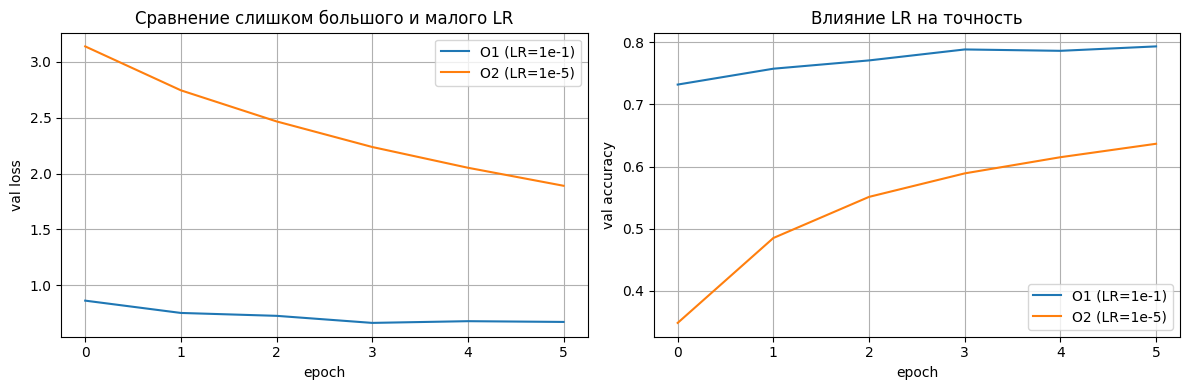

In [14]:
# График для O1 и O2 (LR extremes)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(hist_o1['val_loss'], label='O1 (LR=1e-1)')
plt.plot(hist_o2['val_loss'], label='O2 (LR=1e-5)')
plt.xlabel('epoch')
plt.ylabel('val loss')
plt.title('Сравнение слишком большого и малого LR')
plt.legend()
plt.grid(True)
plt.subplot(1,2,2)
plt.plot(hist_o1['val_acc'], label='O1 (LR=1e-1)')
plt.plot(hist_o2['val_acc'], label='O2 (LR=1e-5)')
plt.xlabel('epoch')
plt.ylabel('val accuracy')
plt.title('Влияние LR на точность')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('artifacts/figures/curves_lr_extremes.png', dpi=150)
plt.show()

In [15]:
# Финальная оценка лучшей модели (E4) на тесте
print("\n=== Финальная оценка лучшей модели (E4) на тесте ===")
test_loss, test_acc = evaluate(model_e4, test_loader, criterion)
print(f"Test loss: {test_loss:.4f}, test accuracy: {test_acc:.4f}")

# Сохранение результатов в runs.csv
df_results = pd.DataFrame(results)
df_results.to_csv('artifacts/runs.csv', index=False)
print("\nСводная таблица результатов:")
print(df_results.to_string())


=== Финальная оценка лучшей модели (E4) на тесте ===
Test loss: 0.4865, test accuracy: 0.8445

Сводная таблица результатов:
  experiment_id          dataset  seed                                             model_summary optimizer       lr momentum  weight_decay  epochs_trained  best_val_accuracy  best_val_loss
0            E1  EMNIST_BALANCED    42  hidden=(256,128), act=ReLU, dropout=0.0, batchnorm=False      Adam  0.00100                 0.0000              10           0.834441       0.514878
1            E2  EMNIST_BALANCED    42  hidden=(256,128), act=ReLU, dropout=0.3, batchnorm=False      Adam  0.00100                 0.0000              10           0.818706       0.554789
2            E3  EMNIST_BALANCED    42   hidden=(256,128), act=ReLU, dropout=0.0, batchnorm=True      Adam  0.00100                 0.0000              10           0.848980       0.454379
3            E4  EMNIST_BALANCED    42   hidden=(256,128), act=ReLU, dropout=0.0, batchnorm=True      Adam  0.00100    